# Topic 2 — K-Nearest Neighbors with Python

Companion notebook for the theory file **`02_K_Nearest_Neighbors.tex`**.

Recall the whole algorithm: *to classify a new point, find its $k$ closest training points (usually by Euclidean distance) and take a majority vote.* Two practical rules dominate everything:
1. **Feature scaling is mandatory** — distances mix all features, so large-scale features drown small ones.
2. **Small $k$ overfits, large $k$ underfits** — pick $k$ with cross-validation or the elbow method.

This notebook has two parts:
1. **Part A** — the mini bootcamp dataset with a cross-validated search over $k$.
2. **Part B** — a full workflow on an anonymised **classified dataset** (`Classified_Data`): a company has hidden the feature column names but given us the data and target classes. We use KNN to predict the class of a new point directly from the features.

## Part A — KNN on the Bootcamp Admissions Data

In [1]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

X = np.array([[2, 45], [4, 55], [5, 60],
              [6, 62], [8, 70], [10, 85]])
y = np.array([0, 0, 0, 1, 1, 1])

# Try several values of k using cross-validation
for k in [1, 3, 5]:
    knn = make_pipeline(StandardScaler(),
                        KNeighborsClassifier(n_neighbors=k))
    scores = cross_val_score(knn, X, y, cv=3)
    print(f"k={k}: mean accuracy = {scores.mean():.2f}")

k=1: mean accuracy = 0.67
k=3: mean accuracy = 0.67
k=5: mean accuracy = nan


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 170, in __call__
    score = scorer(estimator, *args, **routed_params.get(name).score)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 485, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 1135, in score
    return self.steps[-1][1].score(Xt, y, **score_params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py", line 450, in score
    return super().score

In [2]:
# Fit the chosen model and predict for a new applicant (5.5 hours, score 63)
model = make_pipeline(StandardScaler(),
                      KNeighborsClassifier(n_neighbors=3))
model.fit(X, y)
print("Prediction :", model.predict([[5.5, 63]]))
print("Vote shares:", model.predict_proba([[5.5, 63]]))

Prediction : [0]
Vote shares: [[0.66666667 0.33333333]]


**Interpreting the output**

- The cross-validation loop suggests $k=3$ works well here.
- `predict_proba` for KNN reports *vote fractions*: $0.67$ means 2 of the 3 neighbours voted for class 1. These are cruder than logistic regression's smooth probabilities.
- Compare with the by-hand worked example in the theory file: the 3 nearest neighbours of (5.5, 63) vote 2–1 for *Admitted*.

## Part B — Real Data: The Classified Dataset

### Import libraries

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

### Get the data

Set `index_col=0` to use the first column as the index.

In [4]:
df = pd.read_csv('Classified_Data', index_col=0)
df.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


### Standardize the variables

Because the KNN classifier predicts the class of a test observation by identifying the observations nearest to it, **the scale of the variables matters**. Any variables on a large scale will have a much larger effect on the distance between observations — and hence on the classifier — than variables on a small scale.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(df.drop('TARGET CLASS', axis=1))
scaled_features = scaler.transform(df.drop('TARGET CLASS', axis=1))

In [6]:
df_feat = pd.DataFrame(scaled_features, columns=df.columns[:-1])
df_feat.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ
0,-0.123542,0.185907,-0.913431,0.319629,-1.033637,-2.308375,-0.798951,-1.482368,-0.949719,-0.643314
1,-1.084836,-0.430348,-1.025313,0.625388,-0.444847,-1.152706,-1.129797,-0.202240,-1.828051,0.636759
2,-0.788702,0.339318,0.301511,0.755873,2.031693,-0.870156,2.599818,0.285707,-0.682494,-0.377850
3,0.982841,1.060193,-0.621399,0.625299,0.452820,-0.267220,1.750208,1.066491,1.241325,-1.026987
4,1.139275,-0.640392,-0.709819,-0.057175,0.822886,-0.936773,0.596782,-1.472352,1.040772,0.276510


### Train test split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    scaled_features, df['TARGET CLASS'],
    test_size=0.30, random_state=101)

### Using KNN

We start with $k=1$ — the most overfit-prone choice, as the theory file warns (the prediction depends entirely on the single closest point).

In [8]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)

### Predictions and evaluations

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[151   8]
 [ 15 126]]
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       159
           1       0.94      0.89      0.92       141

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



### Choosing a K value — the elbow method

We loop over many values of $k$, record the test error rate for each, and look for the "elbow": the point after which increasing $k$ stops helping.

In [10]:
error_rate = []

# Will take some time
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Error Rate')

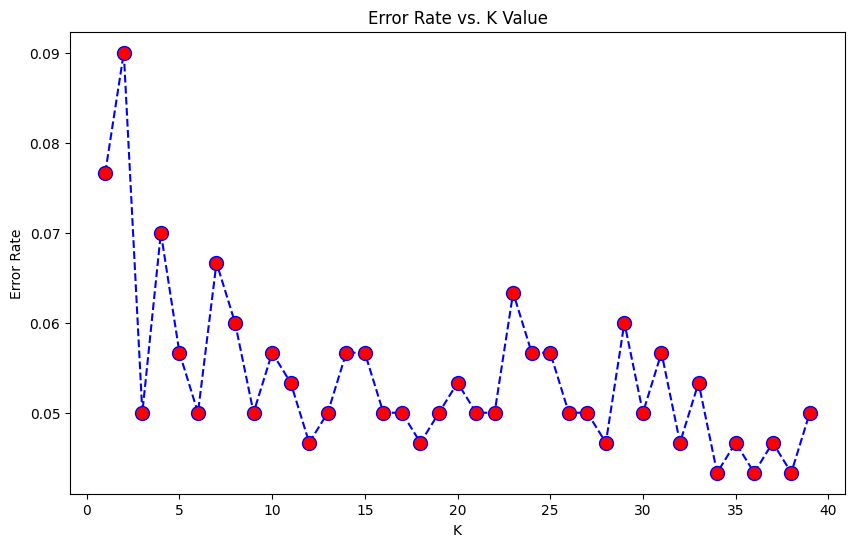

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

After around $k > 23$ the error rate tends to just hover around 0.05–0.06. Let's retrain with a larger $k$ and compare against our original $k=1$:

In [12]:
# FIRST A QUICK COMPARISON TO OUR ORIGINAL K=1
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)

print('WITH K=1')
print('\n')
print(confusion_matrix(y_test, pred))
print('\n')
print(classification_report(y_test, pred))

WITH K=1


[[151   8]
 [ 15 126]]


              precision    recall  f1-score   support

           0       0.91      0.95      0.93       159
           1       0.94      0.89      0.92       141

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



In [13]:
# NOW WITH K=23
knn = KNeighborsClassifier(n_neighbors=23)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)

print('WITH K=23')
print('\n')
print(confusion_matrix(y_test, pred))
print('\n')
print(classification_report(y_test, pred))

WITH K=23


[[150   9]
 [ 10 131]]


              precision    recall  f1-score   support

           0       0.94      0.94      0.94       159
           1       0.94      0.93      0.93       141

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300

